# Manuscript 2 — Figure 4e and Figure S7h
## Probabilistic network traversal: sorting ExN / PN into layers

**Panels produced**

| Panel | Output |
| --- | --- |
| **Fig. 4e** | `figure4_outputs/layers_by_celltype_thresh0.3_exn_then_pn.svg` — violin of per-neuron mean layer, one row per cell type, ExN then PN |
| **Fig. S7h** | `figure4_outputs/threshold_sweep_thresh0.3.svg` (right sub-panel) — cell-type mean layer vs `THRESH` |

Inputs ship with the repository — `data/sensory_exn_to_exn_pn_matrix.csv` and
`data/sensory_exn_to_exn_pn_cell_tags.csv`, built by
`data_generation/build_sensory_exn_matrix.ipynb`. No CAVE query is needed.

> **Environment:** this notebook needs `navis` (`TraversalModel`) and therefore runs in the
> `pymaid` environment, not `cave310`. See `envs/README.md`.


Runs the probabilistic traversal model of Schlegel, Bates et al. (2021) on the
sensory + EXN -> EXN + PN matrix built by `build_sensory_exn_matrix.ipynb`, to assign
each excitatory (EXN) and projection (PN) neuron a **layer** with respect to the
sensory periphery.

**Model.** The non-`ab-ltmr` sensory afferents are the seed population and sit in
layer 1. At every step, each edge from an already-traversed neuron *i* to a
not-yet-traversed neuron *j* gets an independent coin flip with

```
input_fraction_ij = w_ij / input_total_j
p_ij              = min(1, input_fraction_ij / THRESH)
```

so with `THRESH = 0.30` an edge supplying >=30% of the target's input always fires, 10%
fires with p = 0.333, and 2% with p = 0.067. A neuron is traversed as soon as *any* of
its incoming edges fires, and untraversed neurons keep getting fresh chances on later
steps. This repeats for 10,000 iterations, and a neuron's layer is the **mean step at
which it was first encountered**, averaged over iterations. That is deliberately *not*
a shortest-path distance: a neuron reachable only through weak edges lands in a deeper
layer than a directly, strongly driven one even if both are one hop from a seed.

The traversal itself is `navis.models.TraversalModel` — the same implementation used
for the layer analysis in the paper — driven here with a configurable `THRESH`.

**Two assumptions worth knowing about**, both inherited from how the paper normalizes:

1. `input_total_j` is the total input neuron *j* receives **within this matrix**, i.e.
   from the 136 sensory afferents and 177 EXN only. Inhibitory input and anything else
   outside the matrix is not in the denominator, so these are fractions of *traced
   excitatory + sensory* input, not of the neuron's true total input.
2. `ab-ltmr` afferents were dropped upstream, so they contribute to neither the edges
   nor the denominator.


In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

import navis
from navis.models import TraversalModel, random_linear_activation_function

# 10,000 iterations x a tqdm bar per run floods the notebook output
navis.config.pbar_hide = True
sns.set_color_codes("muted")

BASE_DIR = Path("../data")
OUT_DIR = Path("figure4_outputs")
OUT_DIR.mkdir(exist_ok=True)

# --- model parameters -------------------------------------------------------
THRESH_VERSIONS = [0.30, 0.50]   # one full set of figures is produced per value
REF_THRESH = 0.30                # version whose cell-type ordering both figures use
ITERATIONS = 10_000
MAX_STEPS = 50      # hard cap per iteration; checked below to be non-limiting
MIN_SYN = 1         # keep edges with >= this many synapses (the paper used 2)
RANDOM_SEED = 0

# thresholds for the parameter sweep in section 6
THRESH_SWEEP = [0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]
SWEEP_ITERATIONS = 2_000

# --- figure geometry --------------------------------------------------------
# Sizes are exact: tight_layout fits the content inside a fixed canvas and
# savefig is called WITHOUT bbox_inches="tight", which would otherwise resize it.
CM = 1 / 2.54
LAYERS_FIGSIZE = (10 * CM, 6 * CM)   # layers_by_celltype: 10 x 6 cm
SWEEP_FIGSIZE = (12 * CM, 6 * CM)    # threshold_sweep:    12 x 6 cm

FS_TICK, FS_LABEL, FS_TITLE, FS_LEGEND = 5.0, 6.0, 5.5, 4.0

# --- cell types -------------------------------------------------------------
EXN_TAGS = ["adltmr_module", "cltmr_module", "noci_module", "np_module", "r", "v1", "v2"]
PN_TAGS = ["p1", "p2_cold", "p2_noci", "p2_poly"]
LABEL_MAP = {
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

def display_label(tag):
    return LABEL_MAP.get(tag, tag)


## 1) Load the connectivity matrix and cell-type labels

Rows are presynaptic (136 sensory + 177 EXN), columns postsynaptic (177 EXN + 46 PN).
PN are sinks here (postsynaptic only) and sensory are sources (presynaptic only), so
all recurrence in the graph runs through the EXN, which appear on both axes.


In [2]:
matrix = pd.read_csv(BASE_DIR / "sensory_exn_to_exn_pn_matrix.csv", index_col=0)
matrix.index = matrix.index.astype(str)
matrix.columns = matrix.columns.astype(str)

labels = pd.read_csv(BASE_DIR / "sensory_exn_to_exn_pn_cell_tags.csv", dtype={"root_id": str})
tag_of = labels.set_index("root_id")["tag"]
group_of = labels.set_index("root_id")["group"]

print("matrix:", matrix.shape, "|", int(matrix.values.sum()), "synapses in",
      int((matrix.values > 0).sum()), "connections")
print(labels.groupby("group").size().to_string())


matrix: (313, 223) | 24947 synapses in 6506 connections
group
exn        177
pn          46
sensory    136


## 2) Edge list, normalized by the target's total input

`input_fraction` is each edge's share of its target's total input, computed *after* the
`MIN_SYN` filter so the fractions always sum to 1 per target over the edges actually
used by the model (this is what the paper does).


In [3]:
def build_edges(matrix, min_syn=1):
    """Long-form edge list with each edge's fraction of its target's total input."""
    edges = matrix.stack().rename("weight").reset_index()
    edges.columns = ["pre_root_id", "post_root_id", "weight"]
    edges = edges[edges.weight >= min_syn].reset_index(drop=True)

    input_total = edges.groupby("post_root_id").weight.sum()
    edges["input_fraction"] = edges.weight / edges.post_root_id.map(input_total)
    return edges, input_total


edges, input_total = build_edges(matrix, min_syn=MIN_SYN)

print(f"{len(edges)} edges, {int(edges.weight.sum())} synapses (MIN_SYN={MIN_SYN})")
print("\ninput_fraction distribution:")
print(edges.input_fraction.describe(percentiles=[.5, .75, .9, .95, .99]).to_string())
for thr in THRESH_VERSIONS:
    n = (edges.input_fraction >= thr).sum()
    print(f"\n{n} edges ({n / len(edges):.1%}) are at or above THRESH={thr:g} "
          f"and therefore always traverse")


6506 edges, 24947 synapses (MIN_SYN=1)

input_fraction distribution:
count    6506.000000
mean        0.034276
std         0.054183
min         0.001988
50%         0.016949
75%         0.037037
90%         0.073798
95%         0.115688
99%         0.284287
max         0.869565

59 edges (0.9%) are at or above THRESH=0.3 and therefore always traverse

11 edges (0.2%) are at or above THRESH=0.5 and therefore always traverse


## 3) Drop neurons with no connections

A neuron with no edge in either direction can never be traversed and would only show up
as an empty row, so it is dropped. Sensory afferents are presynaptic-only, so a sensory
neuron with no outputs in this matrix is fully isolated.


In [4]:
connected = pd.Index(sorted(set(edges.pre_root_id) | set(edges.post_root_id)))
isolated = labels.loc[~labels.root_id.isin(connected)]

print(f"{len(connected)} of {len(labels)} neurons have at least one connection")
if len(isolated):
    print(f"\ndropped {len(isolated)} unconnected neuron(s):")
    print(isolated[["root_id", "tag", "group"]].to_string(index=False))

seed_ids = labels.loc[labels.group == "sensory", "root_id"]
seed_ids = seed_ids[seed_ids.isin(connected)].tolist()
print(f"\nseed population: {len(seed_ids)} sensory afferents (layer 1)")


358 of 359 neurons have at least one connection

dropped 1 unconnected neuron(s):
           root_id    tag   group
720575940946141316 C-COLD sensory

seed population: 135 sensory afferents (layer 1)


## 4) Run the traversal

Two implementation details that matter:

- **Root IDs are remapped to 0..N-1 indices before the model runs.** `TraversalModel`
  casts its edge list to a single float64 array internally, and 18-digit root IDs are
  not exactly representable in float64 (they shift by up to ~128), so they must not be
  passed through as node names.
- **`model.summary` indexes neurons by `node`** (some `navis` versions instead return
  `node` as an ordinary column, which the code normalizes), and it omits neurons that
  were never traversed. Results are therefore reindexed onto the full node list so
  never-traversed neurons survive as NaN.

`navis` draws from the global numpy RNG, so seeding it makes a serial run reproducible.
The graph is small enough that serial `run()` is several times faster than
`run_parallel()` — process startup dominates — and it is reproducible, so it is used
here.


In [5]:
def run_traversal(edges, seed_ids, thresh=REF_THRESH, iterations=ITERATIONS,
                  max_steps=MAX_STEPS, random_seed=RANDOM_SEED):
    """Return per-neuron layer stats for one traversal run."""
    nodes = pd.Index(sorted(set(edges.pre_root_id) | set(edges.post_root_id)))
    node_idx = pd.Series(np.arange(len(nodes)), index=nodes)

    model_edges = pd.DataFrame({
        "source": edges.pre_root_id.map(node_idx).to_numpy(),
        "target": edges.post_root_id.map(node_idx).to_numpy(),
        "input_fraction": edges.input_fraction.to_numpy(),
    })
    seeds = node_idx.reindex(seed_ids).dropna().astype(int).to_numpy()

    def activation(w, max_w=thresh):
        return random_linear_activation_function(w, 0, max_w)

    np.random.seed(random_seed)
    model = TraversalModel(edges=model_edges, seeds=seeds, weights="input_fraction",
                           max_steps=max_steps, traversal_func=activation)
    results = model.run(iterations=iterations)

    # navis returns `summary` indexed by node in some versions and with `node`
    # as an ordinary column in others; normalize to node-as-index.
    summary = model.summary
    if "node" in summary.columns:
        summary = summary.set_index("node")
    summary["n_seen"] = results.groupby("node").size()
    summary.index = nodes[summary.index]

    layers = summary.reindex(nodes)
    layers["n_seen"] = layers.n_seen.fillna(0).astype(int)
    layers["frac_traversed"] = layers.n_seen / iterations
    layers.index.name = "root_id"
    layers["tag"] = layers.index.map(tag_of)
    layers["group"] = layers.index.map(group_of)
    return layers


In [6]:
# run the model once per threshold version
runs = {}
for thr in THRESH_VERSIONS:
    lay = run_traversal(edges, seed_ids, thresh=thr)
    runs[thr] = lay
    print(f"THRESH={thr:g}: never traversed {int((lay.n_seen == 0).sum())}, "
          f"min frac_traversed {lay.frac_traversed.min():.3f}, "
          f"deepest layer_max {int(lay.layer_max.max())} (MAX_STEPS={MAX_STEPS})")
    if lay.layer_max.max() >= MAX_STEPS:
        print("  WARNING: hit MAX_STEPS -- layer means biased low, raise MAX_STEPS")
    if lay.frac_traversed.min() < 0.99:
        print("  NOTE: some neurons missed in >1% of iterations; their layer_mean "
              "averages only the iterations that reached them")
    assert (lay.loc[seed_ids, "layer_mean"] == 1).all(), "seeds must all be layer 1"

# Both versions share one row order (taken from REF_THRESH) so the two figures are
# directly comparable; the ordering is threshold-invariant anyway (see section 6).
ref = runs[REF_THRESH]
tag_order = (ref[ref.group.isin(["exn", "pn"])]
             .groupby("tag").layer_mean.mean().sort_values().index.tolist())
print("\nrow order:", tag_order)


THRESH=0.3: never traversed 0, min frac_traversed 1.000, deepest layer_max 8 (MAX_STEPS=50)
 

THRESH=0.5: never traversed 0, min frac_traversed 1.000, deepest layer_max 11 (MAX_STEPS=50)

row order: ['adltmr_module', 'p2_cold', 'np_module', 'cltmr_module', 'noci_module', 'p2_noci', 'r', 'p2_poly', 'v2', 'v1', 'p1']


In [7]:
# mean layer per cell type, per version
by_tag = {}
for thr, lay in runs.items():
    by_tag[thr] = (lay[lay.group.isin(["exn", "pn"])]
                   .groupby("tag")
                   .agg(n=("layer_mean", "size"),
                        layer_mean=("layer_mean", "mean"),
                        layer_sd=("layer_mean", "std"),
                        layer_min=("layer_mean", "min"),
                        layer_max=("layer_mean", "max"),
                        frac_traversed=("frac_traversed", "mean"))
                   .loc[tag_order])

pd.concat({f"THRESH={t:g}": b[["n", "layer_mean", "layer_sd"]] for t, b in by_tag.items()},
          axis=1).round(3)


THRESH=0.3                     THRESH=0.5                    
                       n layer_mean layer_sd          n layer_mean layer_sd
tag                                                                        
adltmr_module         15      2.002    0.004         15      2.053    0.039
p2_cold                9      2.003    0.006          9      2.077    0.056
np_module             27      2.022    0.025         27      2.145    0.052
cltmr_module          24      2.028    0.022         24      2.156    0.083
noci_module           10      2.046    0.025         10      2.197    0.062
p2_noci               16      2.096    0.197         16      2.275    0.234
r                     24      2.151    0.141         24      2.386    0.169
p2_poly               15      2.353    0.344         15      2.636    0.442
v2                    36      2.706    0.343         36      2.961    0.378
v1                    41      3.132    0.159         41      3.506    0.203
p1                     6      3.497    0.094          6      3.949    0.094

## 5) Layer plot per EXN / PN cell type

One row per cell type: a violin over the per-neuron layer means, the individual neurons
as dots, and a black tick at the cell-type mean — the presentation used in Figure 3E of
the paper. Sensory afferents are omitted since they are the seeds and sit at layer 1 by
construction.

Rendered at exactly 10 x 6 cm, so fonts are set explicitly rather than left at
matplotlib defaults, and `bbox_inches="tight"` is deliberately not used (it would
override the requested canvas size).


In [8]:
def plot_layers(layers, out_path=None, order=None, title=None,
                figsize=LAYERS_FIGSIZE):
    df = layers[layers.group.isin(["exn", "pn"]) & layers.layer_mean.notna()].copy()
    if order is None:
        order = df.groupby("tag").layer_mean.mean().sort_values().index.tolist()

    palette = dict(zip(order, sns.color_palette("husl", len(order))))
    means = df.groupby("tag").layer_mean.mean().loc[order]
    counts = df.groupby("tag").size().loc[order]

    fig, ax = plt.subplots(figsize=figsize)
    sns.violinplot(data=df, x="layer_mean", y="tag", order=order, orient="h",
                   cut=0, inner=None, scale="width", linewidth=0, palette=palette, ax=ax)
    for coll in ax.collections:
        coll.set_alpha(0.45)
    sns.stripplot(data=df, x="layer_mean", y="tag", order=order, orient="h",
                  size=1.6, alpha=0.9, jitter=0.18, palette=palette,
                  edgecolor="none", ax=ax)
    rows = np.arange(len(order))
    ax.vlines(means.to_numpy(), rows - 0.3, rows + 0.3, colors="k", lw=1.0, zorder=100)

    lo = int(np.floor(df.layer_mean.min()))
    hi = int(np.ceil(df.layer_mean.max()))
    ax.set_xticks(np.arange(lo, hi + 1))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.grid(True, axis="x", which="both", color="0.85", lw=0.5)
    ax.set_axisbelow(True)
    ax.set_xlim(lo - 0.15, hi + 0.15)

    ax.set_yticklabels([f"{display_label(t)}  (n={counts[t]})" for t in order],
                       fontsize=FS_TICK)
    ax.tick_params(axis="x", labelsize=FS_TICK, length=2, pad=1)
    ax.tick_params(axis="y", length=0, pad=1)
    ax.set_xlabel("layer (mean)", fontsize=FS_LABEL, labelpad=2)
    ax.set_ylabel("")
    if title:
        ax.set_title(title, fontsize=FS_TITLE, pad=3)
    sns.despine(left=True)
    fig.tight_layout(pad=0.3)

    if out_path:
        fig.savefig(out_path, format="svg")   # no bbox_inches -> canvas stays 10 x 6 cm
        print("Saved:", out_path)
    plt.show()
    return order


## 6) Effect of the threshold

`THRESH` sets how much of a target's input an edge must supply to guarantee traversal,
so it controls how fast the traversal spreads: a lower value pulls everything toward
layer 2, a higher value stretches the layers apart. The question that matters is
whether it changes the *ordering* of cell types or only the scale, so the sweep below
reports both the per-type means and their rank correlation.

The sweep itself is computed once; each version then renders the same panel with its
own threshold highlighted in red.


In [9]:
sweep = {}
for thr in THRESH_SWEEP:
    lay = run_traversal(edges, seed_ids, thresh=thr, iterations=SWEEP_ITERATIONS)
    sweep[thr] = lay
    sub = lay[lay.group.isin(["exn", "pn"])]
    print(f"THRESH={thr:<5g} mean layer {sub.layer_mean.mean():.2f} "
          f"(range {sub.layer_mean.min():.2f}-{sub.layer_mean.max():.2f}), "
          f"deepest layer_max {int(lay.layer_max.max())}, "
          f"min frac_traversed {lay.frac_traversed.min():.3f}")

sweep_means = pd.DataFrame({
    thr: lay[lay.group.isin(["exn", "pn"])].groupby("tag").layer_mean.mean()
    for thr, lay in sweep.items()
}).loc[tag_order]
sweep_means.columns.name = "THRESH"
sweep_means.round(2)


THRESH=0.05  mean layer 2.20 (range 2.00-3.00), deepest layer_max 3, min frac_traversed 1.000
 

THRESH=0.1   mean layer 2.25 (range 2.00-3.04), deepest layer_max 4, min frac_traversed 1.000
 

THRESH=0.2   mean layer 2.33 (range 2.00-3.34), deepest layer_max 5, min frac_traversed 1.000
 

THRESH=0.3   mean layer 2.42 (range 2.00-3.62), deepest layer_max 8, min frac_traversed 1.000
 

THRESH=0.5   mean layer 2.64 (range 2.00-4.08), deepest layer_max 10, min frac_traversed 1.000
 

THRESH=0.75  mean layer 2.97 (range 2.00-4.66), deepest layer_max 12, min frac_traversed 1.000
 

THRESH=1     mean layer 3.32 (range 2.13-5.34), deepest layer_max 15, min frac_traversed 1.000


THRESH,0.05,0.10,0.20,0.30,0.50,0.75,1.00
tag,,,,,,,
adltmr_module,2.00,2.00,2.00,2.00,2.05,2.22,2.44
p2_cold,2.00,2.00,2.00,2.00,2.08,2.30,2.57
np_module,2.00,2.00,2.00,2.02,2.15,2.37,2.61
cltmr_module,2.00,2.00,2.00,2.03,2.15,2.39,2.66
noci_module,2.00,2.00,2.00,2.05,2.19,2.43,2.68
p2_noci,2.01,2.03,2.05,2.10,2.28,2.56,2.85
r,2.00,2.01,2.06,2.15,2.38,2.69,3.00
p2_poly,2.09,2.12,2.22,2.35,2.63,3.00,3.39
v2,2.24,2.39,2.58,2.71,2.96,3.33,3.73


In [10]:
print(f"rank correlation of cell-type ordering vs THRESH={REF_THRESH:g}:")
for thr in sweep_means.columns:
    rho = spearmanr(sweep_means[thr], sweep_means[REF_THRESH]).correlation
    print(f"  THRESH={thr:<5g} rho={rho:.3f}")


rank correlation of cell-type ordering vs THRESH=0.3:
  THRESH=0.05  rho=0.882
  THRESH=0.1   rho=0.944
  THRESH=0.2   rho=0.989
  THRESH=0.3   rho=1.000
  THRESH=0.5   rho=1.000
  THRESH=0.75  rho=1.000
  THRESH=1     rho=1.000


In [11]:
def plot_threshold_sweep(sweep_means, edges, highlight, out_path=None,
                         figsize=SWEEP_FIGSIZE, order=None):
    order = order or sweep_means.index.tolist()
    palette = dict(zip(order, sns.color_palette("husl", len(order))))

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # left: where the input fractions sit relative to the swept thresholds
    ax = axes[0]
    ax.hist(edges.input_fraction,
            bins=np.logspace(np.log10(edges.input_fraction.min()),
                             np.log10(edges.input_fraction.max()), 40), color="0.6")
    ax.set_xscale("log")
    for thr in sweep_means.columns:
        hit = np.isclose(thr, highlight)
        ax.axvline(thr, color="crimson" if hit else "0.3",
                   lw=1.2 if hit else 0.6, ls="-" if hit else "--")
    ax.set_xlabel("edge input fraction (log)", fontsize=FS_LABEL, labelpad=2)
    ax.set_ylabel("edges", fontsize=FS_LABEL, labelpad=2)
    ax.set_title(f"input fractions (red = THRESH {highlight:g})", fontsize=FS_TITLE, pad=3)

    # right: mean layer per cell type across thresholds
    ax = axes[1]
    for tag in order:
        ax.plot(sweep_means.columns, sweep_means.loc[tag], marker="o", ms=1.8,
                lw=0.8, color=palette[tag], label=display_label(tag))
    ax.axvline(highlight, color="crimson", lw=1.2, zorder=0, alpha=0.6)
    ax.set_xlabel("THRESH (input fraction giving p = 1)", fontsize=FS_LABEL, labelpad=2)
    ax.set_ylabel("layer (mean)", fontsize=FS_LABEL, labelpad=2)
    ax.set_title("cell-type mean layer vs THRESH", fontsize=FS_TITLE, pad=3)
    ax.legend(fontsize=FS_LEGEND, ncol=2, frameon=False, loc="upper left",
              handlelength=1.2, handletextpad=0.4, columnspacing=0.8, labelspacing=0.25)
    ax.grid(True, axis="y", color="0.9", lw=0.5)
    ax.set_axisbelow(True)

    for ax in axes:
        ax.tick_params(labelsize=FS_TICK, length=2, pad=1)
    sns.despine(fig=fig)
    fig.tight_layout(pad=0.3)

    if out_path:
        fig.savefig(out_path, format="svg")   # no bbox_inches -> canvas stays 12 x 6 cm
        print("Saved:", out_path)
    plt.show()


--- THRESH = 0.3 ---


/Users/wangchu/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: FutureWarning: Passing `palette` without assigning `hue` is deprecated.


Saved: figure4_outputs/layers_by_celltype_thresh0.3.svg


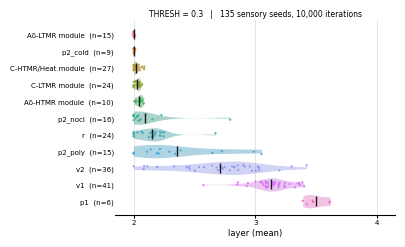

Saved: figure4_outputs/layers_by_celltype_thresh0.3_exn_then_pn.svg


/Users/wangchu/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: FutureWarning: Passing `palette` without assigning `hue` is deprecated.


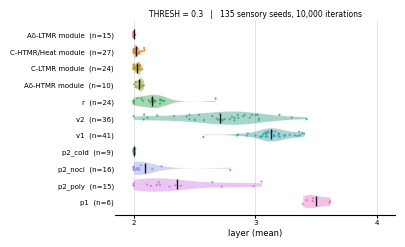

Saved: figure4_outputs/threshold_sweep_thresh0.3.svg


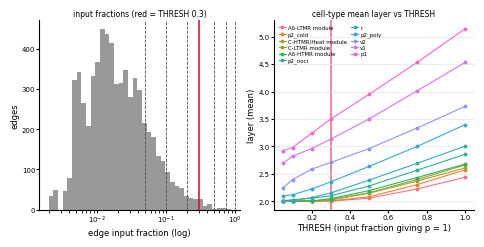

--- THRESH = 0.5 ---


Saved: figure4_outputs/layers_by_celltype_thresh0.5.svg


/Users/wangchu/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: FutureWarning: Passing `palette` without assigning `hue` is deprecated.


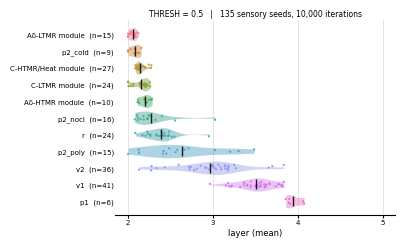

/Users/wangchu/.local/lib/python3.7/site-packages/ipykernel_launcher.py:18: FutureWarning: Passing `palette` without assigning `hue` is deprecated.


Saved: figure4_outputs/layers_by_celltype_thresh0.5_exn_then_pn.svg


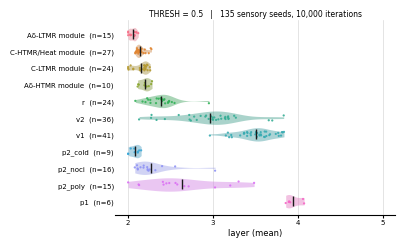

Saved: figure4_outputs/threshold_sweep_thresh0.5.svg


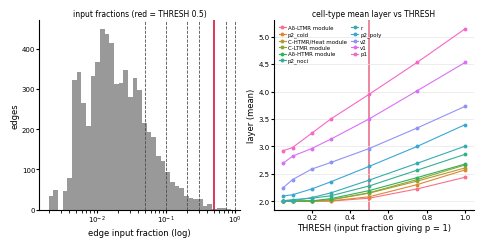

In [12]:
def grouped_order(layers):
    """EXN then PN, each ordered by increasing mean layer."""
    d = layers[layers.group.isin(["exn", "pn"])].groupby(["group", "tag"]).layer_mean.mean()
    return d["exn"].sort_values().index.tolist() + d["pn"].sort_values().index.tolist()


# render both versions: 3 SVGs each
for thr in THRESH_VERSIONS:
    print(f"--- THRESH = {thr:g} ---")
    title = (f"THRESH = {thr:g}   |   {len(seed_ids)} sensory seeds, "
             f"{ITERATIONS:,} iterations")

    plot_layers(runs[thr], order=tag_order, title=title,
                out_path=OUT_DIR / f"layers_by_celltype_thresh{thr:g}.svg")

    # Same data, rows grouped EXN-then-PN. plot_layers assigns the palette by row
    # position, so the top-to-bottom colour sequence is identical to the plot above.
    plot_layers(runs[thr], order=grouped_order(runs[thr]), title=title,
                out_path=OUT_DIR / f"layers_by_celltype_thresh{thr:g}_exn_then_pn.svg")

    plot_threshold_sweep(
        sweep_means, edges, highlight=thr, order=tag_order,
        out_path=OUT_DIR / f"threshold_sweep_thresh{thr:g}.svg",
    )


## 7) Save outputs


In [13]:
for thr in THRESH_VERSIONS:
    lay = runs[thr].copy()
    lay.insert(0, "tag", lay.pop("tag"))
    lay.insert(1, "group", lay.pop("group"))
    lay.to_csv(OUT_DIR / f"neuron_layers_thresh{thr:g}.csv")
    by_tag[thr].to_csv(OUT_DIR / f"celltype_layers_thresh{thr:g}.csv")
    print(f"Saved: neuron_layers_thresh{thr:g}.csv {lay.shape}, "
          f"celltype_layers_thresh{thr:g}.csv {by_tag[thr].shape}")

sweep_means.to_csv(OUT_DIR / "celltype_layers_threshold_sweep.csv")
print("Saved: celltype_layers_threshold_sweep.csv", sweep_means.shape)


Saved: neuron_layers_thresh0.3.csv (358, 8), celltype_layers_thresh0.3.csv (11, 6)
Saved: neuron_layers_thresh0.5.csv (358, 8), celltype_layers_thresh0.5.csv (11, 6)
Saved: celltype_layers_threshold_sweep.csv (11, 7)
